In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
from sklearn.metrics.cluster import adjusted_rand_score
import STAGATE
from scipy import sparse

import tensorflow.compat.v1 as tf
tf.disable_eager_execution()

import warnings
warnings.filterwarnings("ignore")

os.environ['R_HOME'] = '/usr/lib/R'


2024-12-05 11:03:55.557228: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-05 11:03:56.691218: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def save_file(adata, results_path):
    cluster_labels = adata.obs['mclust']
    df = pd.DataFrame({'Id': adata.obs_names, 'Expected': cluster_labels})
    df.to_csv(results_path, index = False)
    

------Calculating spatial graph...
The graph contains 11182 edges, 1950 cells.
5.7344 neighbors per cell on average.
Size of Input:  (1950, 32285)


2024-12-05 11:09:05.514312: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10772 MB memory:  -> device: 0, name: Quadro RTX 5000, pci bus id: 0000:af:00.0, compute capability: 7.5
2024-12-05 11:09:05.514570: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14534 MB memory:  -> device: 1, name: Quadro RTX 5000, pci bus id: 0000:d8:00.0, compute capability: 7.5
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [02:48<00:00,  2.97it/s]


fitting ...
  |======================================================================| 100%


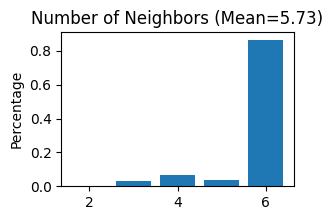

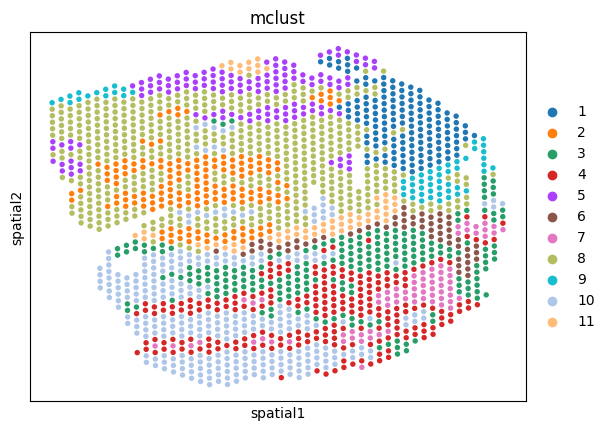

In [5]:
nclusters=11
method_name = "STAGATE"

path = "/data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/mouse_breast_cancer.h5ad"

results_path = "/data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/final_domain_outputs/" \
+ "/output_" + method_name + ".csv"
adata = sc.read_h5ad(path)
    
adata.X = sparse.csr_matrix(adata.X)
STAGATE.Cal_Spatial_Net(adata, rad_cutoff = 250)
STAGATE.Stats_Spatial_Net(adata)

adata = STAGATE.train_STAGATE(adata, alpha = 0)
sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.umap(adata)
adata = STAGATE.mclust_R(adata, used_obsm='STAGATE', num_cluster=nclusters)
save_file(adata, results_path)
sc.pl.embedding(adata, basis = "spatial", color = "mclust")
    